## 1. Data Exploration

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [2]:
# Load the data
# For Google Colab:
#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv('/content/drive/MyDrive/diabetic_data.csv')

df = pd.read_csv('diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Quick overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

---
## 2. Data Cleaning

In [4]:
# Create a clean copy and drop specified columns
df_clean = df.copy()

# Columns to drop as per requirements
cols_to_drop = [
    'weight',           # 97% missing
    'max_glu_serum',    # 83% missing
    'A1Cresult',        # 95% missing
    'encounter_id',     # ID column, not useful for prediction
    'patient_nbr',      # ID column, not useful for prediction
]

In [5]:
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns, {df_clean.shape[1]} remaining")

Dropped 5 columns, 45 remaining


In [6]:
# Fill '?' with 'Missing' for medical_specialty and payer_code instead of dropping
for col in ['medical_specialty', 'payer_code']:
    df_clean[col] = df_clean[col].replace('?', 'Missing')

In [7]:
#Handle '?' in diagnosis
for col in ['diag_1','diag_2','diag_3']:
    df_clean[col] = df_clean[col].replace('?', np.nan)

In [8]:
# Handle Death/Hospice Leakage
# Patients who died or were discharged to hospice cannot be readmitted — keeping them
# would leak the outcome (guaranteed non-readmission) into the training data.
death_hospice_ids = [11, 13, 14, 19, 20, 21]
before = len(df_clean)
df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(death_hospice_ids)]

In [9]:
# Remove invalid gender rows as there are only 3
df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid']

# Reclassify 'Race' which is '?' into 'Other'
df_clean['race'] = df_clean['race'].replace('?', 'Other')
print(df_clean['race'].value_counts())

race
Caucasian          74220
AfricanAmerican    18772
Other               3703
Hispanic            2017
Asian                628
Name: count, dtype: int64


In [10]:
# Convert admission_type_id to binary: emergency vs non-emergency
# Codes: 1:Emergency, 2:Urgent - emergency; 3:Elective, 4+ = Other, non-emergency
df_clean['emergency_admission'] = df_clean['admission_type_id'].isin([1, 2]).astype(int)

print(f"  Emergency (types 1,2): {df_clean['emergency_admission'].sum():,} ({df_clean['emergency_admission'].mean()*100:.1f}%)")
print(f"  Non-emergency:         {(1 - df_clean['emergency_admission']).sum():,} ({(1-df_clean['emergency_admission'].mean())*100:.1f}%)")

# Convert admission_source_id to binary: emergency vs non-emergency
# Code 7: Emergency Room; all others: non-emergency source
df_clean['emergency_source'] = (df_clean['admission_source_id'] == 7).astype(int)
print(f"  ER source (code 7):    {df_clean['emergency_source'].sum():,} ({df_clean['emergency_source'].mean()*100:.1f}%)")
print(f"  Non-ER source:         {(1 - df_clean['emergency_source']).sum():,} ({(1-df_clean['emergency_source'].mean())*100:.1f}%)")

# Drop the original ID columns since we have extracted the binary features
df_clean = df_clean.drop(columns=['admission_type_id', 'admission_source_id'])

  Emergency (types 1,2): 70,501 (71.0%)
  Non-emergency:         28,839 (29.0%)
  ER source (code 7):    55,848 (56.2%)
  Non-ER source:         43,492 (43.8%)


---
## 3. Feature Engineering

### 3.1 Target Variable

For this notebook, the target is **early readmission within 30 days** (`<30`). This is the clinically critical threshold — patients readmitted this quickly often indicate a problem with care quality, discharge planning, or disease management. We encode: **1 = readmitted within 30 days**, **0 = not readmitted or readmitted later**.

In [11]:
# Create binary target: 1 = Readmitted within 30 days (<30), 0 = Not readmitted or >30 days
df_clean['readmitted_binary'] = df_clean['readmitted'].apply(
    lambda x: 1 if x == '<30' else 0
)

target_dist = df_clean['readmitted_binary'].value_counts()
print(f"Not Early Readmitted (0): {target_dist[0]:,} ({target_dist[0]/len(df_clean)*100:.1f}%)")
print(f"Early Readmitted <30 (1): {target_dist[1]:,} ({target_dist[1]/len(df_clean)*100:.1f}%)")
print(f"\nClass imbalance ratio: {target_dist[0]/target_dist[1]:.1f}:1")

df_clean = df_clean.drop(columns=['readmitted'])

Not Early Readmitted (0): 88,026 (88.6%)
Early Readmitted <30 (1): 11,314 (11.4%)

Class imbalance ratio: 7.8:1


### 3.2 ICD-9 Diagnosis Code Mapping

In [12]:
#Map the values in the diagnosis columns with their appropriate diagnosis. Diagnosis codes are referenced from ICD-9
def map_icd9_to_category(code):
    if str(code) == '?' or pd.isna(code): return 'Other'
    code_str = str(code)
    if code_str.startswith('V') or code_str.startswith('E'): return 'Other'
    try: code_num = float(code_str)
    except ValueError: return 'Other'
    val = int(code_num)
    if val == 250: return 'Diabetes'
    elif (val >= 390 and val <= 459) or val == 785: return 'Circulatory'
    elif (val >= 460 and val <= 519) or val == 786: return 'Respiratory'
    elif (val >= 520 and val <= 579) or val == 787: return 'Digestive'
    elif (val >= 800 and val <= 999): return 'Injury'
    elif (val >= 710 and val <= 739): return 'Musculoskeletal'
    elif (val >= 580 and val <= 629) or val == 788: return 'Genitourinary'
    elif (val >= 140 and val <= 239): return 'Neoplasms'
    else: return 'Other'

if 'diag_1' in df_clean.columns and 'diag_2' in df_clean.columns and 'diag_3' in df_clean.columns:
    for col in ['diag_1','diag_2','diag_3']:
        df_clean[f'{col}_group'] = df_clean[col].apply(map_icd9_to_category).astype('category')

    # Drop the original raw ICD-9 code columns (keep the grouped categories)
    df_clean = df_clean.drop(columns=['diag_1','diag_2','diag_3'])
    print(f"  diag_1 categories: {df_clean['diag_1_group'].cat.categories.tolist()}")

  diag_1 categories: ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other', 'Respiratory']


### 3.3 Encode Categorical Variables

In [13]:
# Keep categorical columns as pandas 'category' dtype as LightGBM can use them. LogReg/ Random Forest have to dummy later

# Convert Gender, Race to category
df_clean['gender'] = df_clean['gender'].astype('category')

df_clean['race'] = df_clean['race'].astype('category')

In [14]:
# Convert age ranges to midpoints so they can be used as numerics
age_mapping = {'[0-10)':5,'[10-20)':15,'[20-30)':25,'[30-40)':35,'[40-50)':45,
               '[50-60)':55,'[60-70)':65,'[70-80)':75,'[80-90)':85,'[90-100)':95}
df_clean['age'] = df_clean['age'].map(age_mapping)

In [15]:
# Map change and diabetes med to 1,0
df_clean['change'] = df_clean['change'].map({'No':0,'Ch':1})
df_clean['diabetesMed'] = df_clean['diabetesMed'].map({'No':0,'Yes':1})

In [16]:
# Convert medical_specialty to categorical features based on their codes
def group_specialty(spec):
    spec_lower = str(spec).lower()
    if 'surgery' in spec_lower: return 'Surgery'
    if 'internalmedicine' in spec_lower or 'family' in spec_lower or 'general' in spec_lower: return 'General_Medicine'
    if 'cardiology' in spec_lower: return 'Cardiology'
    if 'emergency' in spec_lower: return 'Emergency'
    if 'nephrology' in spec_lower or 'orthopedics' in spec_lower or 'radiologist' in spec_lower: return 'Specialist'
    return 'Other'

df_clean['medical_specialty'] = df_clean['medical_specialty'].apply(group_specialty).astype('category')
print(df_clean['medical_specialty'].value_counts())

medical_specialty
Other               54899
General_Medicine    21489
Emergency            7422
Cardiology           5285
Specialist           5282
Surgery              4963
Name: count, dtype: int64


In [17]:
# Payer code → group into top 5 paying codes for socio economic grouping
top_payers = df_clean['payer_code'].value_counts().nlargest(5).index.tolist()
df_clean['payer_code'] = df_clean['payer_code'].where(
    df_clean['payer_code'].isin(top_payers), 'Other'
).astype('category')
print(df_clean['payer_code'].value_counts())

payer_code
Missing    39397
MC         31333
Other      12873
HM          6195
SP          4941
BC          4601
Name: count, dtype: int64


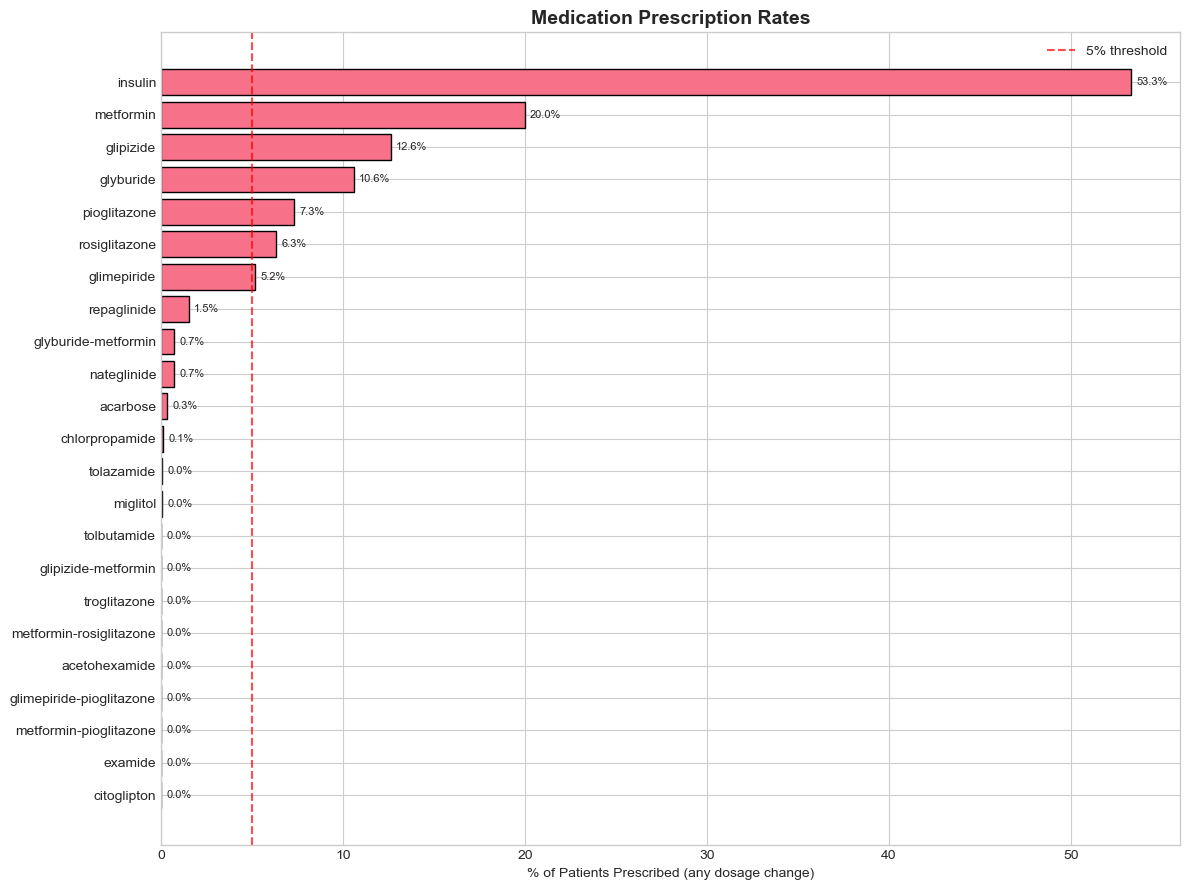

In [18]:
# Medication Column Investigation
# The raw dataset has 23 medication columns. Each contains values: No, Steady, Down, Up.
# We can visualise how often these were administered to decide which to choose
med_cols_original = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone','rosiglitazone',
    'acarbose','miglitol','troglitazone','tolazamide','examide','citoglipton','insulin',
    'glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone']

med_summary = []
for col in med_cols_original:
    if col not in df_clean.columns: continue
    vc = df_clean[col].value_counts()
    no_pct = vc.get('No', 0) / len(df_clean) * 100
    prescribed_pct = 100 - no_pct
    med_summary.append({'medication': col, 'prescribed_pct': prescribed_pct, 'no_pct': no_pct,
                        'steady': vc.get('Steady', 0), 'up': vc.get('Up', 0), 'down': vc.get('Down', 0)})

med_df = pd.DataFrame(med_summary).sort_values('prescribed_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(med_df['medication'], med_df['prescribed_pct'], edgecolor='black')
ax.set_xlabel('% of Patients Prescribed (any dosage change)')
ax.set_title('Medication Prescription Rates', fontsize=14, fontweight='bold')
ax.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='5% threshold')
ax.legend()

for i, (_, row) in enumerate(med_df.iterrows()):
    ax.text(row['prescribed_pct']+0.3, i, f"{row['prescribed_pct']:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
# Medication Feature Engineering
# Keep anything with > 5% prescription rate to capture clinical signal
keep_meds = [
    'insulin', 'metformin', 'glipizide', 'glyburide', 
    'pioglitazone', 'rosiglitazone', 'glimepiride'
]

drop_meds = [
    'repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide', 
    'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 
    'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# Convert kept medications to category dtype
for col in keep_meds:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

# Drop those which have around 2% or less prescription
existing_drop = [c for c in drop_meds if c in df_clean.columns]
df_clean = df_clean.drop(columns=existing_drop)

print(f"Kept medications as categories: {keep_meds}")
print(f"Dropped {len(existing_drop)} near-zero-variance medication columns")
print(f"Dataset shape: {df_clean.shape}")

Kept medications as categories: ['insulin', 'metformin', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'glimepiride']
Dropped 16 near-zero-variance medication columns
Dataset shape: (99340, 29)


In [20]:
# Final dataset overview
cat_cols = df_clean.select_dtypes(include='category').columns.tolist()
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns.tolist()
print(f"Final Dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns ({len(num_cols)}): {num_cols}")

Final Dataset: 99,340 rows × 29 columns

Categorical columns (14): ['race', 'gender', 'payer_code', 'medical_specialty', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'diag_1_group', 'diag_2_group', 'diag_3_group']
Numeric columns (15): ['age', 'discharge_disposition_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'change', 'diabetesMed', 'emergency_admission', 'emergency_source', 'readmitted_binary']


---
## 4. Exploratory Data Analysis (EDA)

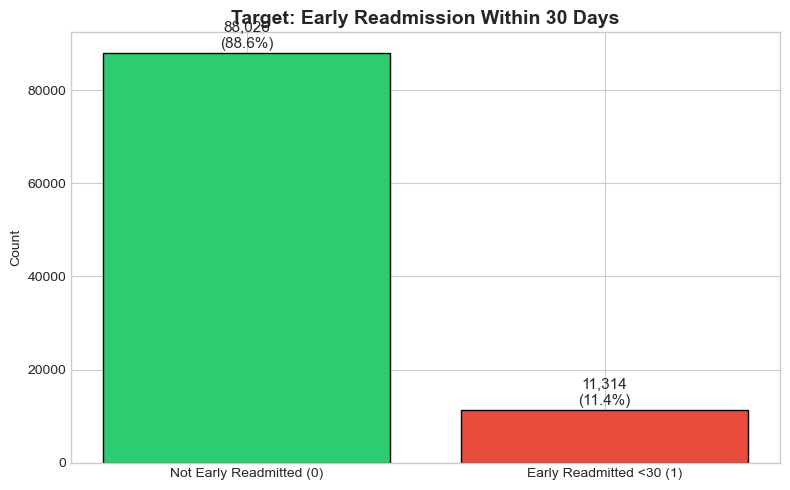

In [21]:
# 4.1 Target variable
fig, ax = plt.subplots(figsize=(8, 5))
colors_binary = ['#2ecc71', '#e74c3c']
target_counts = df_clean['readmitted_binary'].value_counts().sort_index()
bars = ax.bar(['Not Early Readmitted (0)', 'Early Readmitted <30 (1)'], target_counts.values, color=colors_binary, edgecolor='black')
ax.set_title('Target: Early Readmission Within 30 Days', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
for bar, count in zip(bars, target_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000, f'{count:,}\n({count/len(df_clean)*100:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

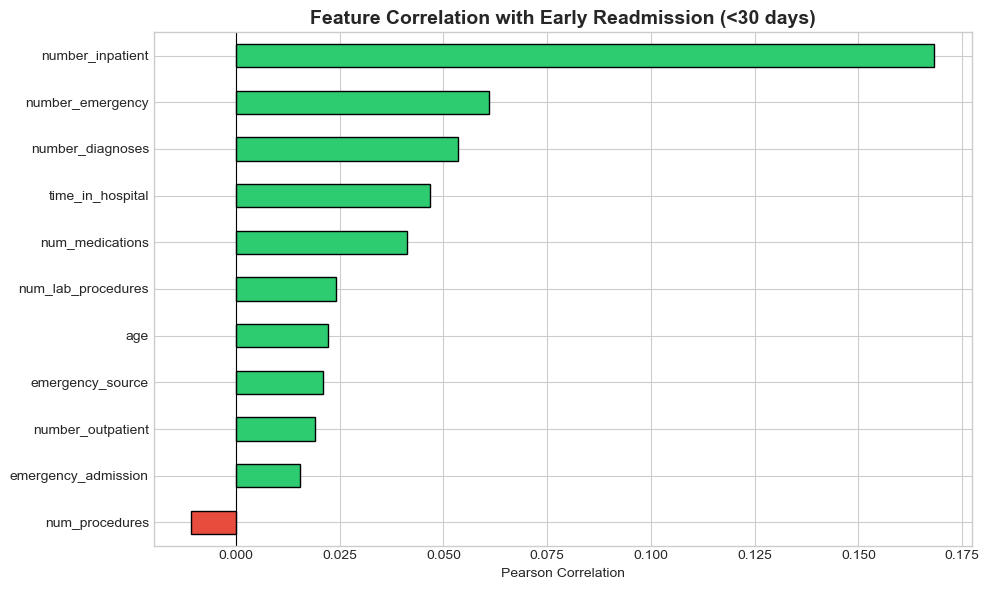

In [22]:
# 4.2 Correlation with target
numerical_cols = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications',
                  'number_outpatient','number_emergency','number_inpatient','number_diagnoses',
                  'age','emergency_admission','emergency_source']
correlations = df_clean[numerical_cols + ['readmitted_binary']].corr()['readmitted_binary'].drop('readmitted_binary').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in correlations.values]
correlations.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
ax.set_title('Feature Correlation with Early Readmission (<30 days)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

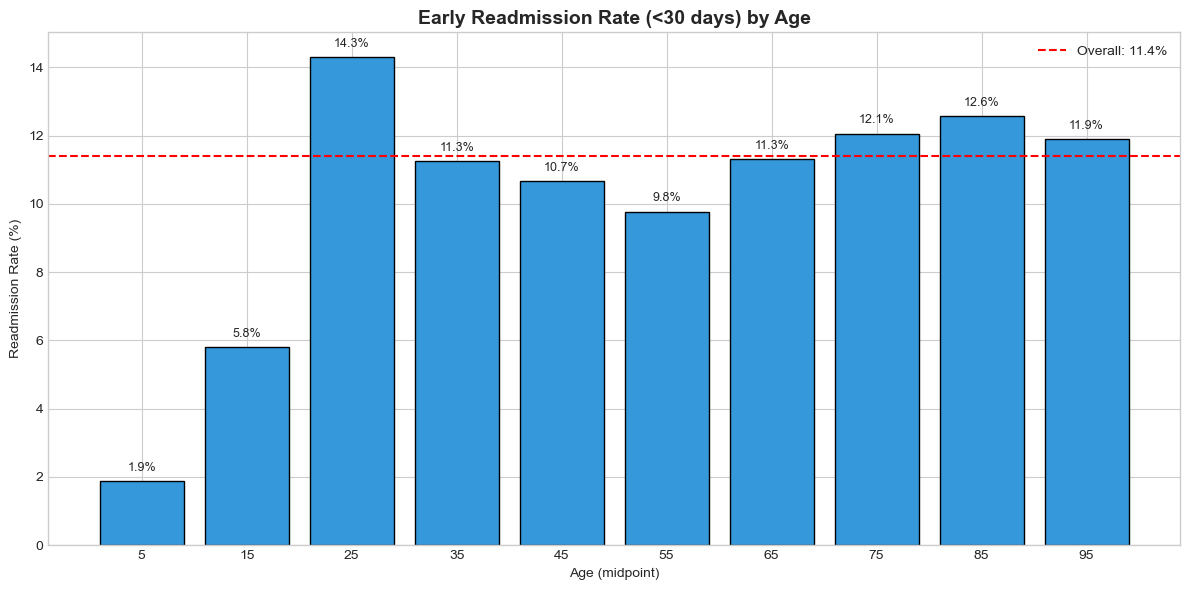

In [23]:
# 4.3 Early Readmission by Age
age_readmit = df_clean.groupby('age')['readmitted_binary'].mean() * 100
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(age_readmit.index.astype(str), age_readmit.values, color='#3498db', edgecolor='black')
ax.set_title('Early Readmission Rate (<30 days) by Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (midpoint)'); ax.set_ylabel('Readmission Rate (%)')
ax.axhline(y=df_clean['readmitted_binary'].mean()*100, color='red', linestyle='--',
           label=f'Overall: {df_clean["readmitted_binary"].mean()*100:.1f}%')
ax.legend()
for bar, val in zip(bars, age_readmit.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

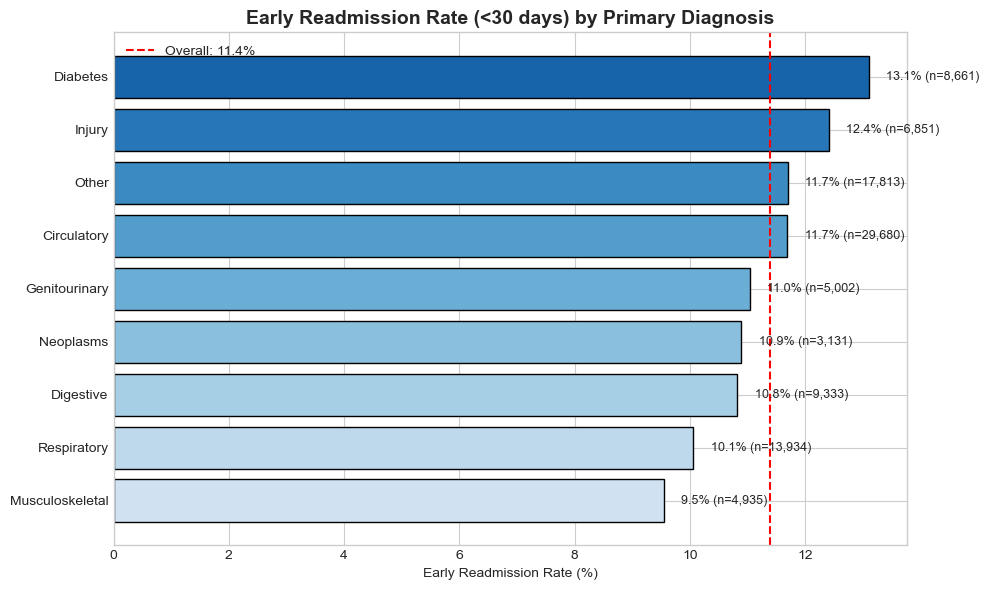

In [24]:
# 4.4 Early Readmission by Primary Diagnosis Group
diag_readmit = df_clean.groupby('diag_1_group')['readmitted_binary'].agg(['mean','count']).reset_index()
diag_readmit.columns = ['category','rate','count']
diag_readmit['rate'] = diag_readmit['rate'] * 100
diag_readmit = diag_readmit.sort_values('rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.2, 0.8, len(diag_readmit)))
ax.barh(diag_readmit['category'].astype(str), diag_readmit['rate'], color=colors, edgecolor='black')
ax.set_xlabel('Early Readmission Rate (%)')
ax.set_title('Early Readmission Rate (<30 days) by Primary Diagnosis', fontsize=14, fontweight='bold')
ax.axvline(x=df_clean['readmitted_binary'].mean()*100, color='red', linestyle='--',
           label=f'Overall: {df_clean["readmitted_binary"].mean()*100:.1f}%')
ax.legend()
for i, (_, row) in enumerate(diag_readmit.iterrows()):
    ax.text(row['rate']+0.3, i, f"{row['rate']:.1f}% (n={row['count']:,.0f})", va='center', fontsize=9)
plt.tight_layout()
plt.show()

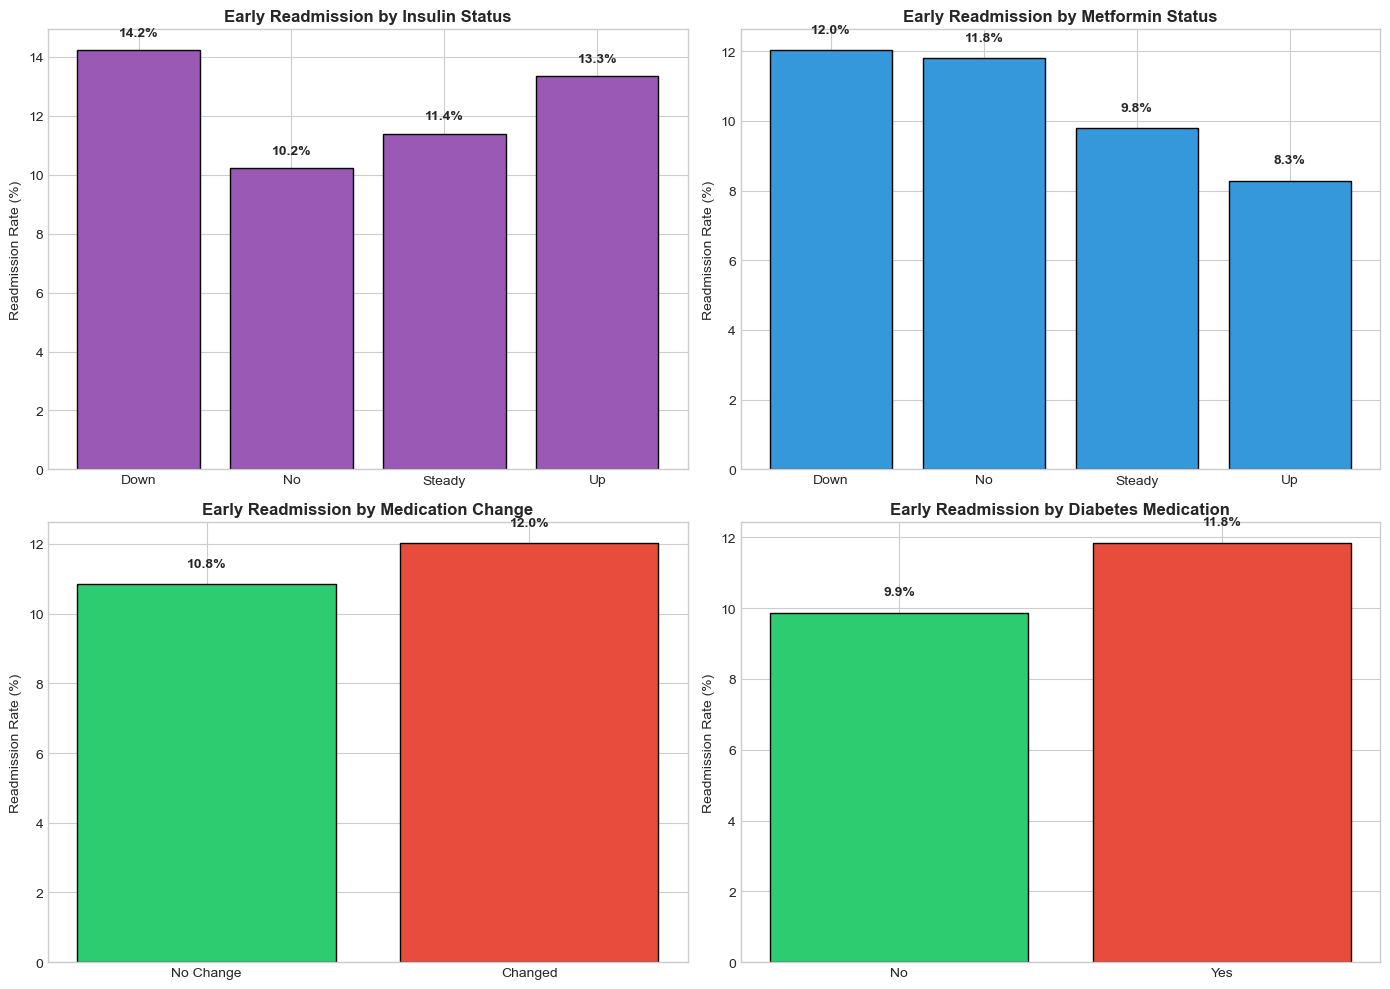

In [25]:
# 4.5 Early Readmission by Medication Variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Insulin
insulin_readmit = df_clean.groupby('insulin')['readmitted_binary'].mean() * 100
axes[0, 0].bar(insulin_readmit.index.astype(str), insulin_readmit.values, color='#9b59b6', edgecolor='black')
axes[0, 0].set_title('Early Readmission by Insulin Status', fontweight='bold')
axes[0, 0].set_ylabel('Readmission Rate (%)')
for i, val in enumerate(insulin_readmit.values):
    axes[0, 0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

# Metformin
metformin_readmit = df_clean.groupby('metformin')['readmitted_binary'].mean() * 100
axes[0, 1].bar(metformin_readmit.index.astype(str), metformin_readmit.values, color='#3498db', edgecolor='black')
axes[0, 1].set_title('Early Readmission by Metformin Status', fontweight='bold')
axes[0, 1].set_ylabel('Readmission Rate (%)')
for i, val in enumerate(metformin_readmit.values):
    axes[0, 1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

# Medication Changed
change_labels = {0: 'No Change', 1: 'Changed'}
change_readmit = df_clean.groupby('change')['readmitted_binary'].mean() * 100
change_readmit.index = change_readmit.index.map(change_labels)
axes[1, 0].bar(change_readmit.index, change_readmit.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1, 0].set_title('Early Readmission by Medication Change', fontweight='bold')
axes[1, 0].set_ylabel('Readmission Rate (%)')
for i, val in enumerate(change_readmit.values):
    axes[1, 0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

# Diabetes Medication
diabmed_labels = {0: 'No', 1: 'Yes'}
diabmed_readmit = df_clean.groupby('diabetesMed')['readmitted_binary'].mean() * 100
diabmed_readmit.index = diabmed_readmit.index.map(diabmed_labels)
axes[1, 1].bar(diabmed_readmit.index, diabmed_readmit.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1, 1].set_title('Early Readmission by Diabetes Medication', fontweight='bold')
axes[1, 1].set_ylabel('Readmission Rate (%)')
for i, val in enumerate(diabmed_readmit.values):
    axes[1, 1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

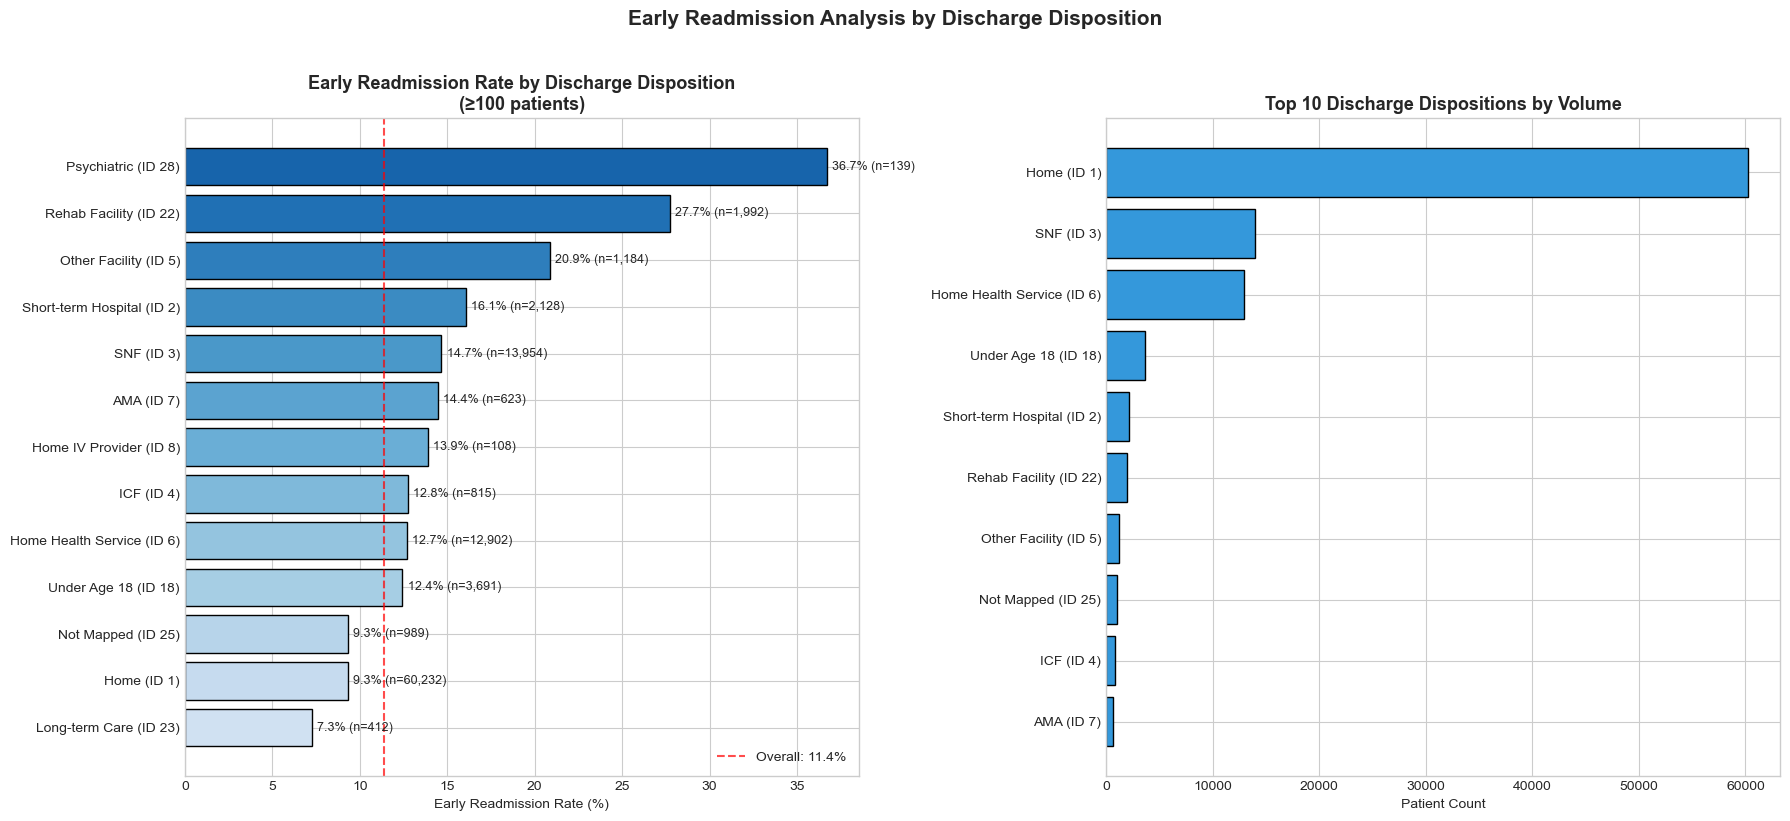

In [26]:
# 4.6 Early Readmission by Discharge Disposition
discharge_labels = {
    1: 'Home', 2: 'Short-term Hospital', 3: 'SNF', 4: 'ICF',
    5: 'Other Facility', 6: 'Home Health Service', 7: 'AMA',
    8: 'Home IV Provider', 9: 'Admitted as Inpatient', 10: 'Neonate',
    12: 'Still Patient', 15: 'Swing Bed', 16: 'Swing Bed (Short-term)',
    17: 'Swing Bed (Short-term)', 18: 'Under Age 18',
    22: 'Rehab Facility', 23: 'Long-term Care', 24: 'Medicaid Certified',
    25: 'Not Mapped', 26: 'Unknown', 27: 'Federal Hospital', 28: 'Psychiatric',
    29: 'Critical Access', 30: 'Another Facility'
}

disch_stats = df_clean.groupby('discharge_disposition_id').agg(
    count=('readmitted_binary', 'size'),
    readmit_rate=('readmitted_binary', 'mean')
).reset_index()
disch_stats['readmit_rate'] = disch_stats['readmit_rate'] * 100
disch_stats['label'] = disch_stats['discharge_disposition_id'].map(discharge_labels).fillna('Other')
disch_stats['display'] = disch_stats['label'] + ' (ID ' + disch_stats['discharge_disposition_id'].astype(str) + ')'

disch_plot = disch_stats[disch_stats['count'] >= 100].sort_values('readmit_rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

colors = plt.cm.Blues(np.linspace(0.2, 0.8, len(disch_plot)))
axes[0].barh(disch_plot['display'], disch_plot['readmit_rate'], color=colors, edgecolor='black')
axes[0].set_xlabel('Early Readmission Rate (%)')
axes[0].set_title('Early Readmission Rate by Discharge Disposition\n(≥100 patients)', fontsize=13, fontweight='bold')
axes[0].axvline(x=df_clean['readmitted_binary'].mean()*100, color='red', linestyle='--', alpha=0.7,
                label=f'Overall: {df_clean["readmitted_binary"].mean()*100:.1f}%')
axes[0].legend()
for i, (_, row) in enumerate(disch_plot.iterrows()):
    axes[0].text(row['readmit_rate']+0.3, i, f"{row['readmit_rate']:.1f}% (n={row['count']:,})", va='center', fontsize=9)

top_volume = disch_stats.nlargest(10, 'count').sort_values('count', ascending=True)
axes[1].barh(top_volume['display'], top_volume['count'], color='#3498db', edgecolor='black')
axes[1].set_xlabel('Patient Count')
axes[1].set_title('Top 10 Discharge Dispositions by Volume', fontsize=13, fontweight='bold')

plt.suptitle('Early Readmission Analysis by Discharge Disposition', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Class Imbalance Handling

Early readmission (`<30` days) is a minority class — roughly **11%** of records versus ~89% non-early-readmissions. This imbalance means a naive model can achieve ~89% accuracy simply by predicting "not readmitted" for everyone — which is clinically useless.

**Strategy: 3:1 Moderate Class Weighting + Threshold Tuning**

- **Why not SMOTE or oversampling?** For a dataset this large (~99K rows), synthetic resampling adds computational cost without meaningful benefit. Class weighting is simpler, faster, and well-supported by all three algorithms.
- **Why 3:1?** The true imbalance is roughly 8-9:1. A 3:1 weight ratio is a *moderate* correction — it boosts minority class sensitivity without overcorrecting and causing the model to hallucinate false positives at a high rate.
- **Threshold tuning** then lets us find the optimal probability cutoff (rather than the default 0.5) to balance Precision and Recall for the clinical use case. In a hospital setting, **missing a true early readmission is more costly than a false alarm**, so we tune toward higher recall.

In [28]:
# Define the class weights dictionary (used by LogReg and Random Forest)
# LightGBM uses scale_pos_weight instead
class_weight_dict = {0: 1.0, 1: 3.0}

# For LightGBM, scale_pos_weight = weight of positive class relative to negative
# With 3:1 moderate weighting: scale_pos_weight = 3.0
lgbm_scale_pos_weight = 3.0

print("Class weighting strategy: 3:1 Moderate")
print(f"  sklearn class_weight: {class_weight_dict}")
print(f"  LightGBM scale_pos_weight: {lgbm_scale_pos_weight}")
print("\nThreshold tuning will be applied after training to optimise recall for clinical use.")

Class weighting strategy: 3:1 Moderate
  sklearn class_weight: {0: 1.0, 1: 3.0}
  LightGBM scale_pos_weight: 3.0

Threshold tuning will be applied after training to optimise recall for clinical use.


---
## 6. Prepare Model

In [29]:
# Prepare feature sets
# LightGBM uses native categorical handling
# LogReg and RF need one-hot encoded dummies

X = df_clean.drop(columns=['readmitted_binary'])
y = df_clean['readmitted_binary']

# Identify categorical columns for LightGBM
cat_cols = X.select_dtypes(include='category').columns.tolist()
print(f"Categorical features for LightGBM: {cat_cols}")
print(f"Total features (LightGBM): {X.shape[1]}, Instances: {X.shape[0]:,}")

# Create one-hot encoded version for LogReg and RF
X_dummies = pd.get_dummies(X, columns=cat_cols, drop_first=False)
print(f"Total features (LogReg/RF after dummies): {X_dummies.shape[1]}")

Categorical features for LightGBM: ['race', 'gender', 'payer_code', 'medical_specialty', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'diag_1_group', 'diag_2_group', 'diag_3_group']
Total features (LightGBM): 28, Instances: 99,340
Total features (LogReg/RF after dummies): 88


In [30]:
# Train-test split: same indices for both feature sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_dum, X_test_dum = X_dummies.loc[X_train.index], X_dummies.loc[X_test.index]

print(f"Training: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train positive rate: {y_train.mean()*100:.1f}% | Test positive rate: {y_test.mean()*100:.1f}%")

Training: 79,472 | Test: 19,868
Train positive rate: 11.4% | Test positive rate: 11.4%


In [31]:
# Scale the dummy features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dum)
X_test_scaled = scaler.transform(X_test_dum)

---
## 7. Model Training: Algorithm Comparison

Train all three algorithms on the same train/test split with **3:1 class weighting** applied. After training, we will apply **threshold tuning** on LightGBM (our best model) to find the optimal decision threshold that balances Precision and Recall for the clinical context.

We begin with a **baseline model** to establish a performance floor — the minimum any meaningful model must beat.

### 7.1 Baseline Model

In [51]:
# 7.1 Baseline — DummyClassifier (Most Frequent & Stratified)
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_dum, y_train)

y_pred_dummy = dummy.predict(X_test_dum)
y_prob_dummy = dummy.predict_proba(X_test_dum)[:, 1]

# Calculate Metrics
metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_dummy),
    'Precision': precision_score(y_test, y_pred_dummy, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_dummy, zero_division=0),
    'F1-Score':  f1_score(y_test, y_pred_dummy, zero_division=0),
    'AUC-ROC':   roc_auc_score(y_test, y_prob_dummy)
}

print
for name, value in metrics.items():
    print(f"  {name:10}: {value:.4f}")

  Accuracy  : 0.8861
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  AUC-ROC   : 0.5000


<h4>The baseline scores high accuracy (~89%) while catching 0% of early readmissions.This is because the dataset itself has a 89% non-readmissions, so the model can easily make accurate predictions by simply choosing 'not readmitted'. We want a model which has a good recall score, meaning one that can actually predict readmissions instead of just predicting non-readmissions. Aiming for 50% </h4>

### 7.2 Logistic Regression

In [33]:
# 7.2 Logistic Regression (uses one-hot encoded features, class_weight applied)
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight=class_weight_dict)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"Logistic Regression stats (using {X_train_dum.shape[1]} one-hot features, class_weight={class_weight_dict})")
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression stats (using 88 one-hot features, class_weight={0: 1.0, 1: 3.0})

Accuracy:  0.8731
Precision: 0.3243
Recall:    0.1052
F1-Score:  0.1588
AUC-ROC:   0.6508


### 7.3 Random Forest

In [34]:
# 7.3 Random Forest (uses one-hot encoded features, class_weight applied)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20,
                                   min_samples_leaf=10, random_state=42, n_jobs=-1,
                                   class_weight=class_weight_dict)
rf_model.fit(X_train_dum, y_train)
y_pred_rf = rf_model.predict(X_test_dum)
y_prob_rf = rf_model.predict_proba(X_test_dum)[:, 1]

print(f"Random Forest stats (using {X_train_dum.shape[1]} one-hot features, class_weight={class_weight_dict})")
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest stats (using 88 one-hot features, class_weight={0: 1.0, 1: 3.0})

Accuracy:  0.8859
Precision: 0.4754
Recall:    0.0128
F1-Score:  0.0250
AUC-ROC:   0.6659


### 7.4 LightGBM + Threshold Tuning

<h4>I used the threshold number as 0.3 rather than the baseline, which is 0.5. This means that the model will flag patients at a 0.3
as likely to readmit rather than 0.5. This means that the model has a higher chance of identifying patients at risk, as the risk
threshold for this model is generally high because of its imbalanced probability.</h4>

In [56]:
# 7.4 LightGBM (uses native categorical handling, scale_pos_weight for class balancing)
lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=64,
    scale_pos_weight=lgbm_scale_pos_weight,  # 3:1 moderate weighting
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(
    X_train, y_train,
    categorical_feature=cat_cols
)

y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
tuned_threshold = 0.3
y_pred_lgbm = (y_prob_lgbm >= tuned_threshold).astype(int)

print(f"LightGBM stats (scale_pos_weight={lgbm_scale_pos_weight}, default threshold=0.3)")

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgbm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_lgbm):.4f}")

LightGBM stats (scale_pos_weight=3.0, default threshold=0.3)

Accuracy:  0.7084
Precision: 0.1946
Recall:    0.4971
F1-Score:  0.2797
AUC-ROC:   0.6709


In [58]:
results = {}
for name, (pred, prob) in {
    "Baseline (Most Freq)": (y_pred_baseline_mf, y_prob_baseline_mf),
    "LogReg": (y_pred_lr, y_prob_lr),
    "RandomForest": (y_pred_rf, y_prob_rf),
    "LightGBM": (y_pred_lgbm, y_prob_lgbm)
}.items():
    results[name] = [
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        f1_score(y_test, pred, zero_division=0),
        roc_auc_score(y_test, prob)
    ]

model_metrics = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1", "AUC"])
model_metrics

,Baseline (Most Freq),LogReg,RandomForest,LightGBM
Accuracy,0.886098,0.873113,0.885947,0.708426
Precision,0.000000,0.324251,0.475410,0.194637
Recall,0.000000,0.105170,0.012815,0.497128
F1,0.000000,0.158825,0.024957,0.279746
AUC,0.500000,0.650771,0.665868,0.670867


<h4>LightGBM with tuned threshold delivers the best balance of Recall (catching the most actual early readmissions) and F1 score. Class weighting ensures all models learn from the minority class despite the imbalance. AUC-ROC reflects the model's ability to discriminate early readmissions regardless of threshold choice.</h4>

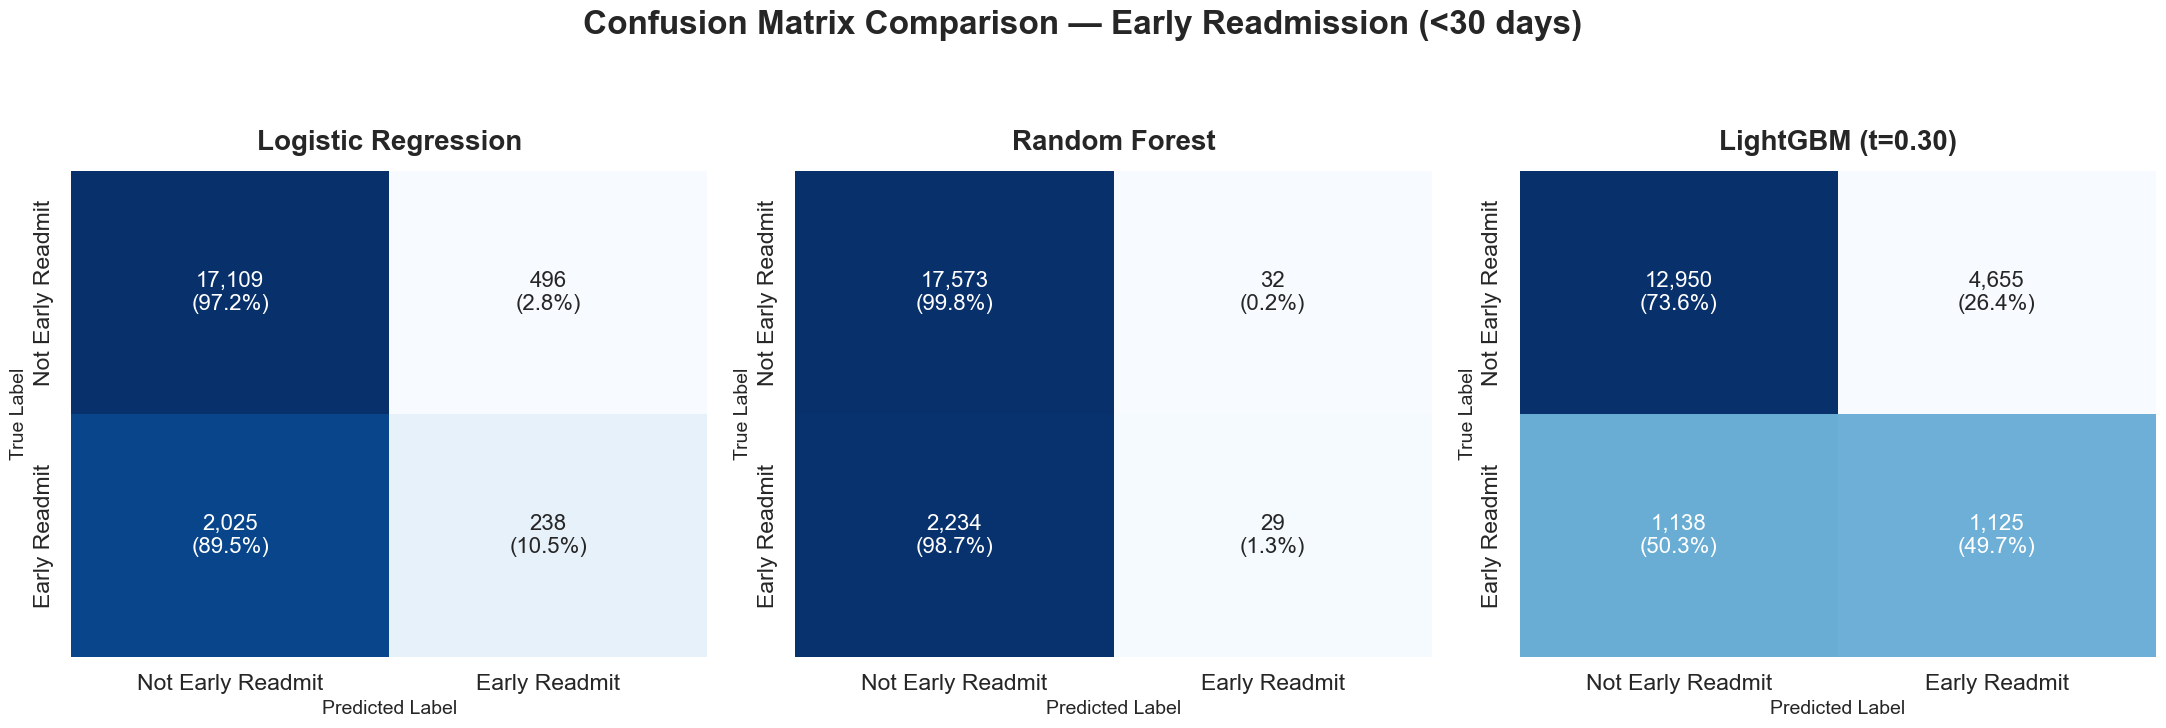

In [60]:
sns.set_theme(style="white", context="talk") 
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    (f'LightGBM (t={tuned_threshold:.2f})', y_pred_lgbm)
]

for idx, (name, y_pred) in enumerate(models_info):
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    labels = np.array([[f'{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)' for j in range(2)] for i in range(2)])
    
    sns.heatmap(cm_norm, annot=labels, fmt='', cmap='Blues', ax=axes[idx],
                xticklabels=['Not Early Readmit', 'Early Readmit'],
                yticklabels=['Not Early Readmit', 'Early Readmit'],
                annot_kws={"size": 16}, cbar=False)
    
    axes[idx].set_title(f'{name}', fontsize=20, fontweight='bold', pad=15)
    axes[idx].set_xlabel('Predicted Label', fontsize=14)
    axes[idx].set_ylabel('True Label', fontsize=14)

plt.suptitle('Confusion Matrix Comparison — Early Readmission (<30 days)', 
             fontsize=24, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

<h4>LightGBM with the tuned threshold captures the most actual early readmissions (highest Recall). In a clinical context, it is better to flag more patients for follow-up (higher false positives) than to miss patients who genuinely need urgent post-discharge support.</h4>

---
## 8. Feature Importance Analysis

In [40]:
# LightGBM Feature Importance
lgbm_importance = pd.DataFrame({'feature':X.columns,'importance':lgbm_model.feature_importances_}).sort_values('importance',ascending=False)

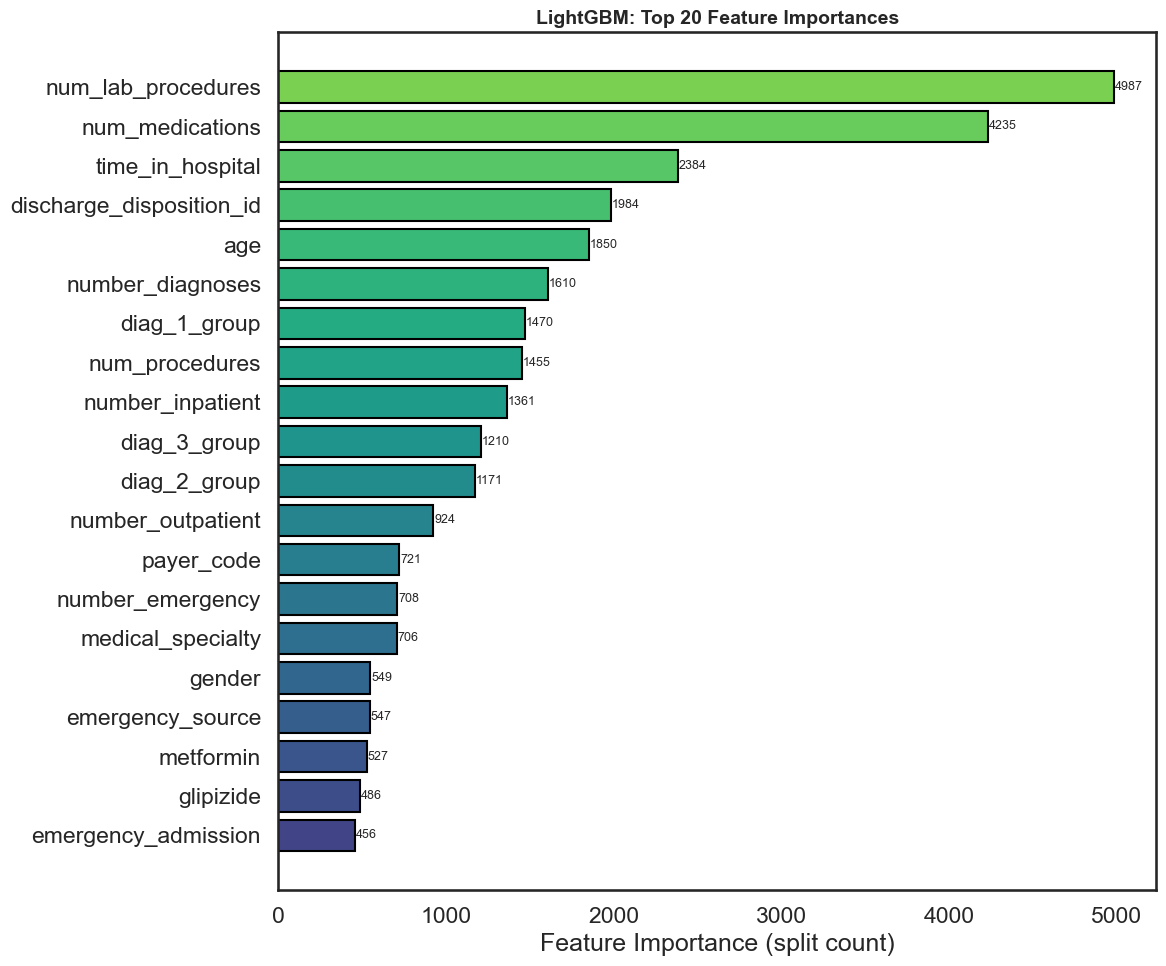

In [41]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(12, 10))
top_20 = lgbm_importance.head(20).sort_values('importance')
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_20)))
ax.barh(top_20['feature'], top_20['importance'], color=colors, edgecolor='black')
ax.set_xlabel('Feature Importance (split count)')
ax.set_title('LightGBM: Top 20 Feature Importances', fontsize=14, fontweight='bold')
for i, (_, row) in enumerate(top_20.iterrows()):
    ax.text(row['importance']+5, i, f"{row['importance']:.0f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

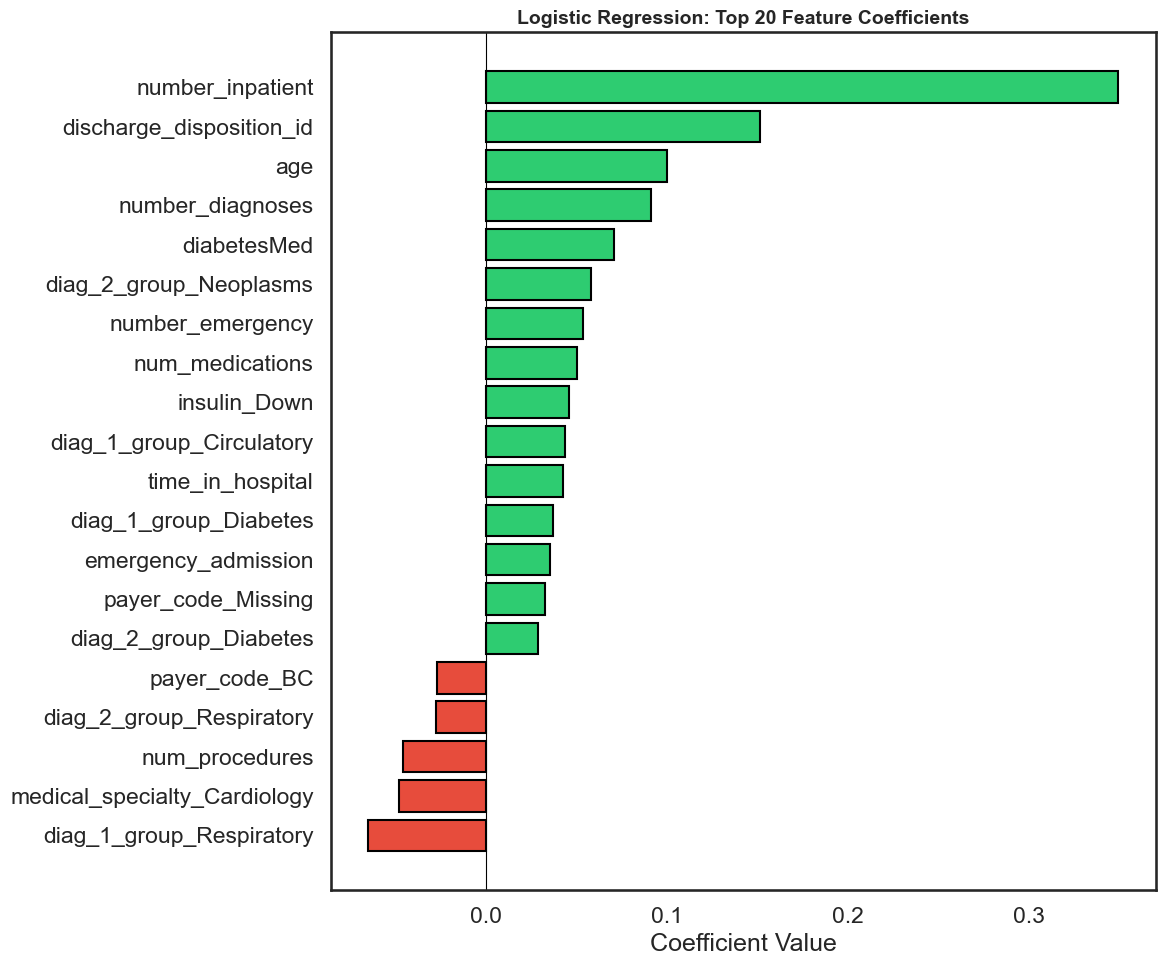

In [42]:
# Logistic Regression Coefficients (uses one-hot encoded features)
lr_importance = pd.DataFrame({'feature':X_dummies.columns,'coefficient':lr_model.coef_[0]}).sort_values('coefficient',key=abs,ascending=False)
fig, ax = plt.subplots(figsize=(12, 10))
top_20_lr = lr_importance.head(20).sort_values('coefficient')
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in top_20_lr['coefficient']]
ax.barh(top_20_lr['feature'], top_20_lr['coefficient'], color=colors, edgecolor='black')
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression: Top 20 Feature Coefficients', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## 9. Exporting Predictive Model for Tableau


In [43]:
# Score the full dataset using LightGBM with tuned threshold
df_scored = df_clean.copy()

df_scored["readmit_probability"] = lgbm_model.predict_proba(X)[:, 1]
df_scored["predicted_readmit"] = (df_scored["readmit_probability"] >= optimal_threshold).astype(int)

# Select columns for Tableau dashboard
cols_to_export = [
    # Predictions
    "predicted_readmit",
    "readmit_probability",
    "readmitted_binary",
    
    # Demographics
    "age",
    "gender",
    "race",
    
    # Hospital stay
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    
    # Medical management
    "change",
    "diabetesMed",
    "insulin",
    "metformin",
    
    # Admission/discharge
    "discharge_disposition_id",
    "emergency_admission",
    "emergency_source",
    
    # Diagnosis groups
    "diag_1_group",
    "diag_2_group",
    "diag_3_group",
    
    # Other categoricals
    "medical_specialty",
    "payer_code",
]

# Filter to only include columns that actually exist
cols_to_export = [c for c in cols_to_export if c in df_scored.columns]

# Export to CSV
df_scored[cols_to_export].to_csv("EarlyReadmissions_under30_predictions.csv", index=False)

print(f"Exported: EarlyReadmissions_under30_predictions.csv")
print(f"- Rows: {len(df_scored):,}")
print(f"- Columns: {len(cols_to_export)}")
print(f"- Threshold used: {optimal_threshold:.2f}")
print(f"\nColumns included:")
for c in cols_to_export:
    print(f"  {c}")

Exported: EarlyReadmissions_under30_predictions.csv
- Rows: 99,340
- Columns: 24
- Threshold used: 0.32

Columns included:
  predicted_readmit
  readmit_probability
  readmitted_binary
  age
  gender
  race
  time_in_hospital
  num_lab_procedures
  num_medications
  number_inpatient
  number_emergency
  number_outpatient
  change
  diabetesMed
  insulin
  metformin
  discharge_disposition_id
  emergency_admission
  emergency_source
  diag_1_group
  diag_2_group
  diag_3_group
  medical_specialty
  payer_code
